In [16]:
!pip install keras-visualizer
!pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot
import seaborn as sns
from keras.datasets import fashion_mnist
from keras_visualizer import visualizer
from keras.utils import to_categorical
from keras_visualizer import visualizer
from keras.initializers import HeNormal, RandomNormal
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization
from keras.optimizers import Adam
from keras.losses import CategoricalCrossentropy

In [ ]:
dataset = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(type(dataset))

<class 'tuple'>


In [ ]:
import numpy as np
np.set_printoptions(linewidth=200, threshold=np.inf)

for i in range(0,2):
  print(dataset[i])

Buffered data was truncated after reaching the output size limit.

In [17]:
print(f"Shape of training images (dataset[0][0]): {dataset[0][0].shape}")
print(f"Shape of training labels (dataset[0][1]): {dataset[0][1].shape}")
print(f"Shape of test images (dataset[1][0]): {dataset[1][0].shape}")
print(f"Shape of test labels (dataset[1][1]): {dataset[1][1].shape}")

Shape of training images (dataset[0][0]): (60000, 28, 28)
Shape of training labels (dataset[0][1]): (60000,)
Shape of test images (dataset[1][0]): (10000, 28, 28)
Shape of test labels (dataset[1][1]): (10000,)


In [21]:
print(dataset[0][0][2])

[[  0   0   0   0   0   0   0   0   0  22 118  24   0   0   0   0   0  48  88   5   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  12 100 212 205 185 179 173 186 193 221 142  85   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  85  76 199 225 248 255 238 226 157  68  80   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  91  69  91 201 218 225 209 158  61  93  72   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  79  89  61  59  87 108  75  56  76  97  73   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  75  89  80  80  67  63  73  83  80  96  72   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  77  88  77  80  83  83  83  83  81  95  76   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  89  96  80  83  81  84  85  85  85  97  84   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  93  97  81  85  84  85  87  88  84  99  8

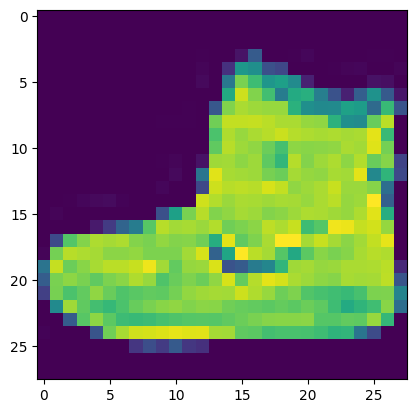

In [ ]:
pyplot.imshow(dataset[0][0][0])

In [22]:
#splitting the dataset into train and validation
(x_train, y_train), (x_val, y_val) = fashion_mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_val.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_val.shape == (10000,)

In [23]:
# check the unique value in dataset
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [24]:
# converting the train and validation data into categorical values
y_train_cat = to_categorical(y_train)
y_val_cat = to_categorical(y_val)

In [25]:
y_train_cat[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [38]:
from keras.src.models import sequential
fashion_model = Sequential()
fashion_model.add(Conv2D(input_shape=(28,28,1), padding="valid", kernel_size=(3,3), strides=(2,2),
                         filters=32, activation="relu", kernel_initializer=HeNormal, use_bias=False))
fashion_model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
fashion_model.add(Flatten())
fashion_model.add(Dense(100, activation="relu", kernel_initializer=HeNormal, use_bias=False))
fashion_model.add(BatchNormalization())
fashion_model.add(Dense(10, activation="softmax", kernel_initializer=HeNormal, use_bias=False))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
fashion_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,888 (456.59 KB)

 Trainable params: 116,688 (455.81 KB)

 Non-trainable params: 200 (800.00 B)

In [40]:
fashion_model.compile(optimizer=Adam(), loss=CategoricalCrossentropy(), metrics=["accuracy"])

In [41]:
fashion_history=fashion_model.fit(x_train, y_train_cat, epochs=100,
                                  batch_size=10000, validation_data=(x_val, y_val_cat),
                                  verbose=2)

Epoch 1/100
6/6 - 4s - 634ms/step - accuracy: 0.4683 - loss: 1.5762 - val_accuracy: 0.5954 - val_loss: 3.8328
Epoch 2/100
6/6 - 0s - 39ms/step - accuracy: 0.7326 - loss: 0.7551 - val_accuracy: 0.7112 - val_loss: 1.8523
Epoch 3/100
6/6 - 0s - 38ms/step - accuracy: 0.7752 - loss: 0.6353 - val_accuracy: 0.7508 - val_loss: 1.1400
Epoch 4/100
6/6 - 0s - 39ms/step - accuracy: 0.7953 - loss: 0.5762 - val_accuracy: 0.7766 - val_loss: 0.8892
Epoch 5/100
6/6 - 0s - 37ms/step - accuracy: 0.8118 - loss: 0.5346 - val_accuracy: 0.7910 - val_loss: 0.7507
Epoch 6/100
6/6 - 0s - 37ms/step - accuracy: 0.8251 - loss: 0.5028 - val_accuracy: 0.7995 - val_loss: 0.6771
Epoch 7/100
6/6 - 0s - 37ms/step - accuracy: 0.8347 - loss: 0.4764 - val_accuracy: 0.8058 - val_loss: 0.6271
Epoch 8/100
6/6 - 0s - 36ms/step - accuracy: 0.8424 - loss: 0.4555 - val_accuracy: 0.8146 - val_loss: 0.5882
Epoch 9/100
6/6 - 0s - 37ms/step - accuracy: 0.8486 - loss: 0.4372 - val_accuracy: 0.8193 - val_loss: 0.5542
Epoch 10/100
6/6 -

In [42]:
fashion_model.evaluate(x_val, y_val_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8814 - loss: 0.3802


[0.38020020723342896, 0.8813999891281128]

In [ ]:
# export the x_val and y_val_cat into an csv file


In [43]:
import pandas as pd

# Flatten x_val images from (10000, 28, 28) to (10000, 784)
x_val_flat = x_val.reshape(x_val.shape[0], -1)

# Create a DataFrame for flattened x_val
x_val_df = pd.DataFrame(x_val_flat)

# Create column names for y_val_cat (e.g., 'label_0', 'label_1', ...)
label_cols = [f'label_{i}' for i in range(y_val_cat.shape[1])]
y_val_df = pd.DataFrame(y_val_cat, columns=label_cols)

# Concatenate the image data and label data horizontally
combined_df = pd.concat([x_val_df, y_val_df], axis=1)

# Export to CSV
file_path = 'fashion_mnist_val_data.csv'
combined_df.to_csv(file_path, index=False)

print(f"Successfully exported validation data to {file_path}")

Successfully exported validation data to fashion_mnist_val_data.csv


In [45]:
y_val_df

,label_0,label_1,label_2,label_3,label_4,label_5,label_6,label_7,label_8,label_9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
y_validation_df = pd.DataFrame(y_val, columns=['label'])

In [53]:
# add id as first column of y_validation_df starting fro 60001
y_validation_df.insert(0, 'id', range(60001, 70001))

In [55]:
y_validation_df.to_csv('fashion_mnist_val_labels.csv', index=False)